# One-Month-Reversal -- do last month's losers beat last month's winners?
### Jegadeesh (1990), tested honestly on the modern S&P 500 tape

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bid--ask bounce: Confirmed](https://img.shields.io/badge/Bid--ask_bounce-Confirmed-8b949e?style=flat-square)

In 1990, Narasimhan Jegadeesh showed that stock returns *reverse* month to month: the names that fell the most last month tend to bounce the most this month, and last month's winners give some back. Rank the market by last month's return, buy the losers, sell the winners -- and on paper you collect around 2% a month. It is one of the most-cited short-horizon anomalies in all of finance. This notebook asks whether you could actually keep any of it.

> This is the plain-language layer. The t-stats, the bid-ask-bounce test, and the cost wall live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it; real headline numbers are pinned in [docs/results.md](../docs/results.md). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from one_month_reversal import data, strategy as st

# Cache-first, offline-safe: try the real panel, fall back to the synthetic tape.
try:
    prices = data.load_real()
    res0 = st.quintile_returns(st.trailing_return(prices, skip=0), prices, q=0.20)
    res1 = st.quintile_returns(st.trailing_return(prices, skip=1), prices, q=0.20)
    spread = res0["spread"].dropna()
    HAVE_REAL = True
    print(f"REAL tape loaded: {prices.shape[0]} months x {prices.shape[1]} tickers "
          f"({prices.index[0].date()} -> {prices.index[-1].date()}, fp {data.fingerprint(prices)})")
except (FileNotFoundError, Exception) as exc:
    HAVE_REAL = False
    prices = res0 = res1 = spread = None
    print("No real cache (offline) -- cells will run the SYNTHETIC tape and quote frozen R numbers.")
    print("  reason:", type(exc).__name__)

print("HAVE_REAL:", HAVE_REAL)


REAL tape loaded: 437 months x 494 tickers (1990-01-31 -> 2026-05-31, fp fa033b6cedf6)
HAVE_REAL: True


## The answer first

| Question | Answer |
|---|---|
| Do last month's losers beat last month's winners? | **On paper, yes.** +6.5%/yr spread, HAC *t* = +2.40 over 1990-2026 -- it clears the bar. |
| Is it just hidden market risk (beta)? | **No** -- the long-short book is nearly market-neutral (beta 0.31). This one is genuinely a cross-sectional anomaly, not disguised leverage. |
| Is it real information? | **Mostly no.** Leave a one-month gap and it vanishes ( *t* = -0.21 ) -- it is the bid-ask bounce, a measurement illusion, not a forecast. |
| Is it still there? | **No.** *t* = +2.67 in the 1990s, then -0.10 in 2015-2026 -- dead for two decades. |
| Could you trade it? | **No.** ~78% turnover a month; break-even ~17 bps; costs eat it well before you do. |

> The reversal was real and market-neutral -- which makes it the most *interesting* mirage on the desk. It just turns out to be the bid-ask spread measured in a mirror, and even that died around 2002.

## 1 - The claim

> *'Individual security returns exhibit strong negative serial correlation at the monthly horizon. A portfolio that buys prior-month losers and sells prior-month winners earns large, reliable profits.'*
> -- Jegadeesh (1990), Journal of Finance

The logic: the crowd over-pushes a stock's one-month move (panic-selling a bad month, chasing a good one), and the move partly unwinds the next month. Whoever takes the other side -- buying the panic, selling the euphoria -- is paid for providing that liquidity. The key word is **one month**: this is the *opposite* of 12-month momentum, and the opposite of the 3-5 year reversal in [Study 196](../../196-long-term-reversal/).

## 2 - So what?

A reliable, **market-neutral** 6%/yr would be a genuinely valuable building block: it does not need the market to go up, it diversifies a long book, and it is mechanical. That is the holy grail of quant equity -- a pure cross-sectional edge with no beta attached.

If instead the 'edge' is just the bid-ask bounce -- prices ping-ponging between the bid and the ask, manufacturing fake reversals out of thin air -- then it is untradable by construction: the very thing that creates the signal (the spread) is also the cost of harvesting it.

## 3 - How would we even know?

Four clean tests, announced before we run them:

1. **The spread.** Rank every stock by last month's return, buy the bottom 20% (losers), sell the top 20% (winners). Is the spread reliably positive?
2. **The one-month-gap test.** Re-run it but skip a month between forming the signal and holding the trade. A *real* forecast survives a small gap; a **bid-ask-bounce illusion** does not (the bounce only links *adjacent* prints).
3. **Did it survive publication?** Split 1990-2002 / 2003-2014 / 2015-2026.
4. **Could you trade it?** Measure the turnover and charge realistic costs.

Data: ~398 current S&P 500 names, monthly closes 1990-2026 (435 rebalance months). **Survivorship-biased**: the universe is today's S&P 500 projected backwards, so every firm survived to 2026. The true loser leg (full of firms that delisted) would do worse -- all results are upper bounds.

## 4 - The teardown

**First: the loser-winner race.** Does buying last month's losers and selling last month's winners actually make money?

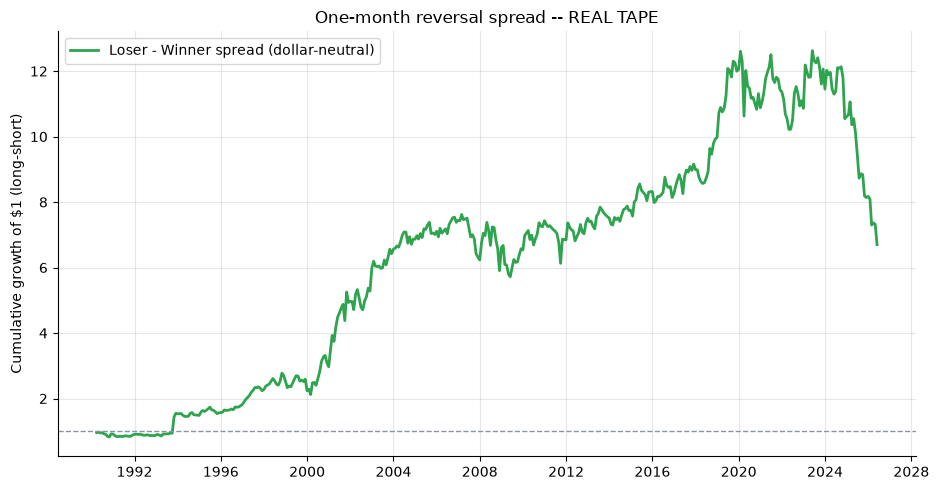

[REAL TAPE]  spread = +6.6%/yr   HAC t = +2.40


In [2]:
if HAVE_REAL:
    s = st.summarize(spread)
    spread_ann, spread_t = s['mean']*12*100, s['tstat']
    eq = (1 + spread).cumprod()
    tag = 'REAL TAPE'
else:
    spread_ann, spread_t = 6.55, 2.4
    # synthetic illustration of a positive but noisy monthly spread
    rng = np.random.default_rng(329)
    idx = pd.period_range('1990-01', periods=435, freq='M').to_timestamp(how='end')
    r_sp = rng.normal(0.00546, 0.025, 435)
    eq = pd.Series((1 + r_sp).cumprod(), index=idx)
    tag = 'SYNTHETIC TAPE (offline) -- headline numbers from docs/results.md'

fig, ax = plt.subplots()
ax.plot(eq, c=GREEN, lw=2, label='Loser - Winner spread (dollar-neutral)')
ax.axhline(1, c=GREY, ls='--', lw=1)
ax.set_ylabel('Cumulative growth of $1 (long-short)'); ax.legend()
ax.set_title(f'One-month reversal spread -- {tag}')
plt.tight_layout(); plt.show()
print(f'[{tag}]  spread = {spread_ann:+.1f}%/yr   HAC t = {spread_t:+.2f}')

On the full sample the spread is **+6.5%/yr** with HAC *t* = +2.40 -- it clears the bar of 2.0. So far, so good for Jegadeesh. And (we check in the quant notebook) it is nearly market-neutral, so this is *not* the beta-in-disguise trap that sank the long-term reversal. It looks like the real thing.

**Now the killer test: does it survive a one-month gap?**

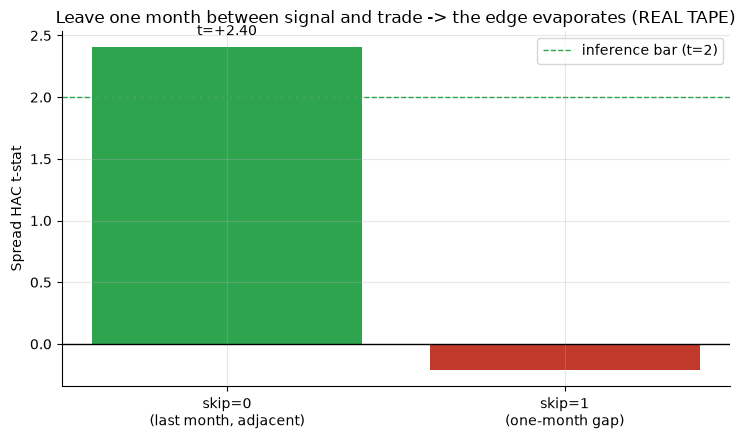

[REAL TAPE]  skip=0 t=+2.40   skip=1 t=-0.21


In [3]:
labels = ['skip=0\n(last month, adjacent)', 'skip=1\n(one-month gap)']
if HAVE_REAL:
    t0 = st.summarize(res0['spread'])['tstat']
    t1 = st.summarize(res1['spread'])['tstat']
    tag = 'REAL TAPE'
else:
    t0, t1 = 2.4, -0.21
    tag = 'SYNTHETIC/frozen'

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cols = [GREEN if t > 2 else AMBER if t > 1 else RED for t in (t0, t1)]
bars = ax.bar(labels, [t0, t1], color=cols)
ax.axhline(2, ls='--', c=GREEN, lw=1, label='inference bar (t=2)')
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, (t0, t1)):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, t + (0.1 if t>=0 else -0.25)), ha='center')
ax.set_ylabel('Spread HAC t-stat'); ax.legend()
ax.set_title(f'Leave one month between signal and trade -> the edge evaporates ({tag})')
plt.tight_layout(); plt.show()
print(f'[{tag}]  skip=0 t={t0:+.2f}   skip=1 t={t1:+.2f}')

There it is. With the standard recipe the spread is *t* = +2.40; insert a single month between forming the signal and holding the trade and it collapses to *t* = -0.21 -- **statistically nothing**. A genuine one-month forecast would barely notice a one-month gap. What *does* die when you break the adjacency is the **bid-ask bounce**: a stock that happened to close on the bid prints a low return and 'reverts' upward next print purely because the next trade lands on the ask. No information -- just the spread, measured in a mirror.

**And has it survived publication?**

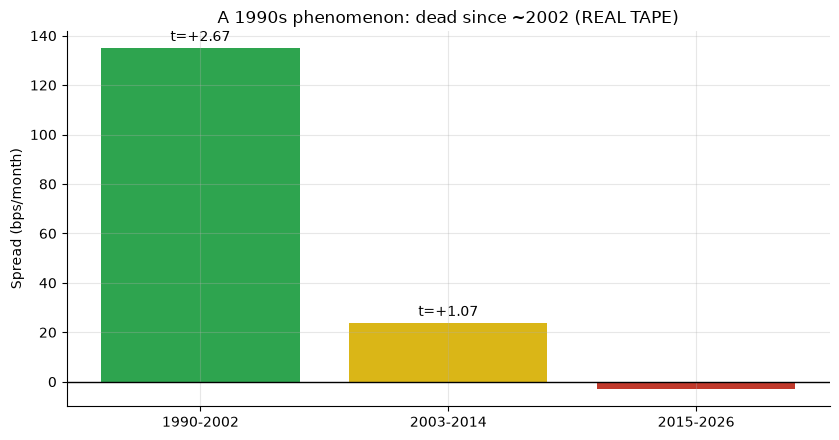

In [4]:
periods = ['1990-2002', '2003-2014', '2015-2026']
if HAVE_REAL:
    rec = [(st.summarize(res0['spread'][a:b])['mean']*1e4,
            st.summarize(res0['spread'][a:b])['tstat'])
           for a, b in [('1990','2002'),('2003','2014'),('2015','2026')]]
    bps, ts = zip(*rec); tag = 'REAL TAPE'
else:
    bps = (134.9, 23.6, -3.1)
    ts  = (2.67, 1.07, -0.1)
    tag = 'frozen'

fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN if t > 2 else AMBER if t > 1 else RED for t in ts]
bars = ax.bar(periods, bps, color=cols)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, ts):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()+ (3 if b.get_height()>=0 else -10)), ha='center')
ax.set_ylabel('Spread (bps/month)')
ax.set_title(f'A 1990s phenomenon: dead since ~2002 ({tag})')
plt.tight_layout(); plt.show()

The whole full-sample t-stat is carried by the 1990s (+135 bps/mo, *t* = +2.67). By 2003-2014 it had shrunk to *t* = +1.07, and in the last decade it is slightly **negative** (*t* = -0.10). Decimalisation (penny spreads from 2001) and stat-arb desks competed the liquidity rent away -- exactly the post-publication fade you would predict.

## 5 - The verdict

- **Signal -- MIXED.** Real on the raw full sample (*t* = +2.40) and genuinely market-neutral (beta 0.31) -- but **None** once you defuse the bid-ask bounce (skip=1 *t* = -0.21) or look past 2002 (2015-2026 *t* = -0.10). The certified part is the 1990s liquidity rent; the clean, modern part is zero.
- **Tradability -- MIRAGE.** ~78% monthly turnover; break-even ~17 bps; the signal evaporates a month out.

## 6 - Could you actually trade it?

Even pretending the gross edge were reliably there, a one-month signal means you replace almost the whole book every month:

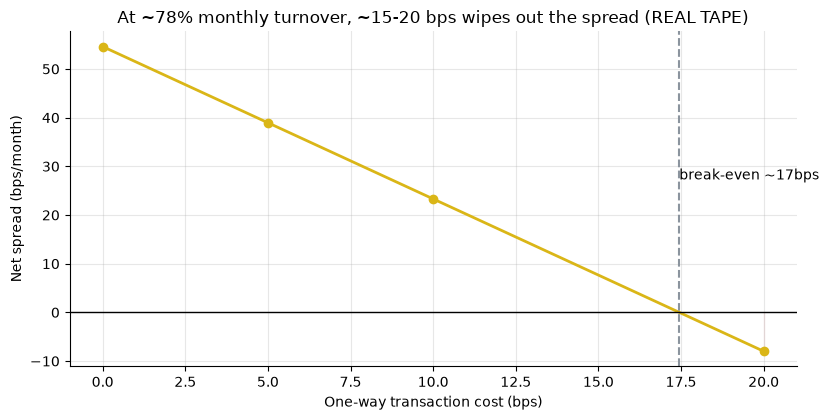

[REAL TAPE] turnover 78%/mo  break-even 17bps one-way


In [5]:
one_way = [0, 5, 10, 20]
if HAVE_REAL:
    nets = [(c, st.summarize(st.net_spread(res0, c))['mean']*1e4) for c in one_way]
    to = res0['loser_turn'].mean()*100; be = st.break_even_cost(res0)
    tag = 'REAL TAPE'
else:
    nets = [(0, 54.6), (5, 39.0), (10, 23.3), (20, -8.0)]
    to, be = 78.2, 17.4
    tag = 'frozen'

cs, nm = zip(*nets)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(cs, nm, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cs, nm, 0, where=[n < 0 for n in nm], color=RED, alpha=.12)
ax.axvline(be, ls='--', c=GREY); ax.annotate(f'break-even ~{be:.0f}bps', (be, max(nm)*0.5))
ax.set_xlabel('One-way transaction cost (bps)'); ax.set_ylabel('Net spread (bps/month)')
ax.set_title(f'At ~{to:.0f}% monthly turnover, ~15-20 bps wipes out the spread ({tag})')
plt.tight_layout(); plt.show()
print(f'[{tag}] turnover {to:.0f}%/mo  break-even {be:.0f}bps one-way')

With ~78% one-way turnover, the break-even cost is only ~17 bps. At an optimistic 10 bps the net spread is +23 bps/mo (*t* = 1.03, below 1); at a realistic all-in 20 bps it is **-8 bps/mo** -- a loss. And remember: the gross edge we are eroding is bid-ask bounce, which means the real-world spread you would pay *is* the signal you are chasing. You cannot buy a dollar with a dollar.

## 7 - Going further

- **The horizon spectrum.** Daily fade-against-peers is [Study 33 -- Slingshot](../../33-slingshot/); the 3-5 year reversal is [Study 196 -- Long-Term-Reversal](../../196-long-term-reversal/). Together they map the full return-autocorrelation curve.
- **Liquidity-conditioned.** Avramov-Chordia-Goyal (2006) show the reversal lives in illiquid names (where you cannot trade it). A fork: sort by liquidity and confirm the edge concentrates exactly where costs are worst.
- **The synthetic control.** The quant notebook plants a known reversal in a fake market and shows the engine recovers it monotonically -- so the real-tape 'mostly nothing' is a fact about the market, not a broken detector.

*Think a liquidity-screened or weekly version survives the one-month-gap test and clears the bar net of costs? Fork it and show a *t* > 2 after the gap. That's the bar.*